<a href="https://colab.research.google.com/github/yafiqzacky9-tech/TUBES-Smart-Inventory-Management/blob/main/Smart%20inventory%20management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib

In [33]:
df = pd.read_csv("inventory_dataset.csv")

df.head()

,item_id,nama_barang,kategori,supplier,gudang,satuan,harga_beli,harga_jual,stok_saat_ini,stok_minimum,stok_maksimum,avg_penjualan_harian,stockout_days,lead_time_hari,transaksi_30hari,terjual_30hari,persen_stok,days_of_supply,perlu_reorder
0,ITM-00001,Barang_1,Otomotif,CV Anugrah Perdana,Gudang D,set,126361,166548,381,51,357,19.91,20.0,5,8.0,672,106.72,19.14,1
1,ITM-00002,Barang_2,Makanan & Minuman,PT Maju Jaya,Gudang C,liter,217986,297460,85,85,425,2.40,12.0,2,5.0,77,20.00,35.42,1
2,ITM-00003,Barang_3,Pakaian,CV Anugrah Perdana,Gudang A,roll,202286,295602,274,51,306,17.18,5.0,27,64.0,364,89.54,15.95,1
3,ITM-00004,Barang_4,Otomotif,CV Anugrah Perdana,Gudang D,set,363320,413973,226,22,132,9.86,5.0,13,2.0,364,171.21,22.92,0
4,ITM-00005,Barang_5,Furnitur,PT Maju Jaya,Gudang B,pack,497508,593443,459,35,245,16.63,10.0,17,73.0,391,187.35,27.60,1


In [34]:
print(df.shape)

df.info()

(2515, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2515 entries, 0 to 2514
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   item_id               2515 non-null   object 
 1   nama_barang           2515 non-null   object 
 2   kategori              2515 non-null   object 
 3   supplier              2515 non-null   object 
 4   gudang                2515 non-null   object 
 5   satuan                2515 non-null   object 
 6   harga_beli            2515 non-null   int64  
 7   harga_jual            2515 non-null   int64  
 8   stok_saat_ini         2515 non-null   int64  
 9   stok_minimum          2515 non-null   int64  
 10  stok_maksimum         2515 non-null   int64  
 11  avg_penjualan_harian  2430 non-null   float64
 12  stockout_days         2450 non-null   float64
 13  lead_time_hari        2515 non-null   int64  
 14  transaksi_30hari      2443 non-null   float64
 15  terjual_30

In [35]:
print(df.isnull().sum())

item_id                  0
nama_barang              0
kategori                 0
supplier                 0
gudang                   0
satuan                   0
harga_beli               0
harga_jual               0
stok_saat_ini            0
stok_minimum             0
stok_maksimum            0
avg_penjualan_harian    85
stockout_days           65
lead_time_hari           0
transaksi_30hari        72
terjual_30hari           0
persen_stok              0
days_of_supply           0
perlu_reorder            0
dtype: int64


In [36]:
df.fillna(
    df.median(numeric_only=True),
    inplace=True
)

In [37]:
print("Duplicates:",
      df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicates: 15


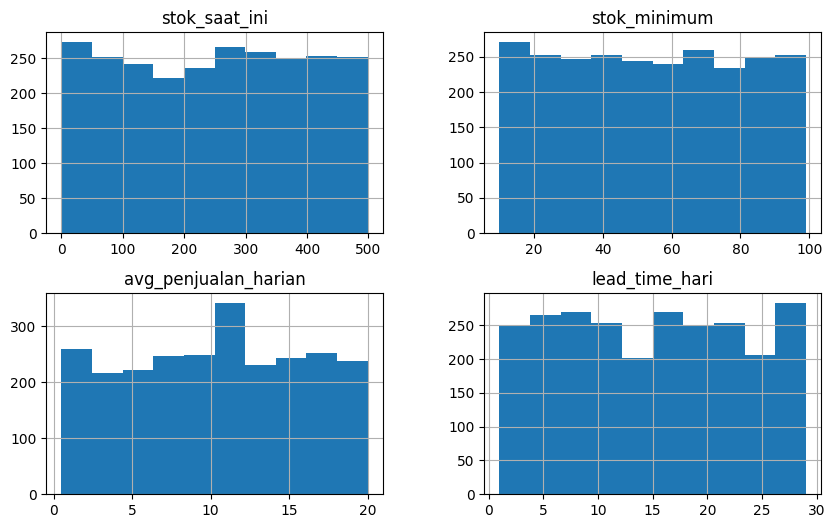

In [38]:
df[
    [
        'stok_saat_ini',
        'stok_minimum',
        'avg_penjualan_harian',
        'lead_time_hari'
    ]
].hist(figsize=(10,6))

plt.show()

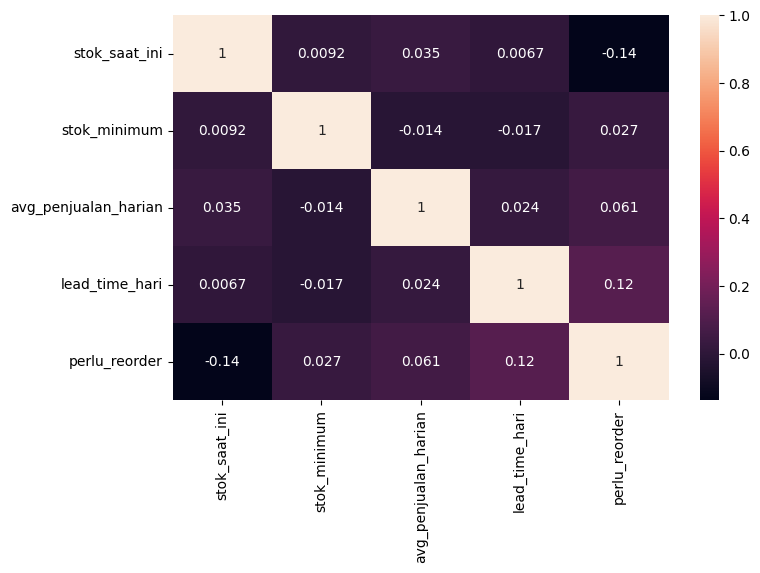

In [39]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[
        [
            'stok_saat_ini',
            'stok_minimum',
            'avg_penjualan_harian',
            'lead_time_hari',
            'perlu_reorder'
        ]
    ].corr(),
    annot=True
)

plt.show()

In [40]:
X = df[
    [
        'stok_saat_ini',
        'stok_minimum',
        'avg_penjualan_harian',
        'lead_time_hari'
    ]
]

y = df['perlu_reorder']

In [41]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_prediction = dt_model.predict(
    X_test
)

In [44]:
dt_accuracy = accuracy_score(
    y_test,
    dt_prediction
)

print(
    "Decision Tree Accuracy:",
    dt_accuracy
)

Decision Tree Accuracy: 0.806


In [45]:
print(
    classification_report(
        y_test,
        dt_prediction
    )
)

              precision    recall  f1-score   support

           0       0.20      0.22      0.21        58
           1       0.90      0.88      0.89       442

    accuracy                           0.81       500
   macro avg       0.55      0.55      0.55       500
weighted avg       0.82      0.81      0.81       500



In [46]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_prediction = rf_model.predict(
    X_test
)

In [47]:
rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)

print(
    "Random Forest Accuracy:",
    rf_accuracy
)

Random Forest Accuracy: 0.88


In [48]:
print(
    classification_report(
        y_test,
        rf_prediction
    )
)

              precision    recall  f1-score   support

           0       0.38      0.05      0.09        58
           1       0.89      0.99      0.94       442

    accuracy                           0.88       500
   macro avg       0.63      0.52      0.51       500
weighted avg       0.83      0.88      0.84       500



In [49]:
print(
    "Decision Tree:",
    dt_accuracy
)

print(
    "Random Forest:",
    rf_accuracy
)

Decision Tree: 0.806
Random Forest: 0.88


In [50]:
joblib.dump(
    rf_model,
    "model_inventory.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Model saved successfully")

Model saved successfully


In [51]:
joblib.dump(
    rf_model,
    "model_inventory.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Model saved successfully")

Model saved successfully


In [52]:
import streamlit as st
import joblib
import numpy as np

model = joblib.load("model_inventory.pkl")
scaler = joblib.load("scaler.pkl")

st.title("Inventory Reorder Prediction")

current_stock = st.number_input(
    "Current Stock",
    min_value=0
)

minimum_stock = st.number_input(
    "Minimum Stock",
    min_value=0
)

avg_daily_sales = st.number_input(
    "Average Daily Sales",
    min_value=0
)

lead_time_days = st.number_input(
    "Lead Time (Days)",
    min_value=0
)

if st.button("Predict"):

    data = np.array([[
        current_stock,
        minimum_stock,
        avg_daily_sales,
        lead_time_days
    ]])

    data_scaled = scaler.transform(data)

    prediction = model.predict(
        data_scaled
    )

    if prediction[0] == 1:
        st.error("⚠ Need Reorder")
    else:
        st.success("✅ No Reorder Needed")

2026-06-15 09:28:28.220 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 09:28:28.684 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-15 09:28:28.688 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 09:28:28.690 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 09:28:28.691 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 09:28:28.695 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 09:28:28.696 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 09:28:28.700 Thread 'MainThread': mi